Purpose: Find genes (CAM-annotated & other) overlapping between time-structured (and/or DE), ASE, and HybridExpress gene sets.<br>
Author: Anna Pardo<br>
Date initiated: May 6, 2026

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from venn import venn
import json

In [10]:
# load time-structured DE gene info
ygde = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/Yg_maSigPro_DEGs_allphys.txt",sep="\t",header="infer")
ygde.head()

,GeneID,nsets,phys,species
0,YufilH1064049m.g,10,CAM,Yg
1,YufilH1024614m.g,9,CAM,Yg
2,Yucal.17G091000.v2.1,9,CAM,Yg
3,Yucal.15G051100.v2.1,9,CAM,Yg
4,Yucal.17G065400.v2.1,9,CAM,Yg


In [13]:
# load time-structured genes (regardless of DE)
c3cam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/C3+CAM_TSgenes_9gt.txt",sep="\t",header="infer")
cam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/CAM_TSgenes_9gt.txt",sep="\t",header="infer")
faccam = pd.read_csv("/home/leviathan22/yucca-genomics/masigpro/facCAM_TSgenes_9gt.txt",sep="\t",header="infer")

In [24]:
cam.head()

,GeneID,subgenome,physiology
0,Yucal.12G110700.v2.1,Ya,CAM
1,YufilH1093583m.g,Yf,CAM
2,Yucal.04G084700.v2.1,Ya,CAM
3,Yucal.10G075200.v2.1,Ya,CAM
4,Yucal.03G222100.v2.1,Ya,CAM


In [30]:
allts = pd.concat([c3cam,cam,faccam])

In [11]:
# load CAM annotation (will probably need this)
camannot = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [14]:
# load ASE info
ase = pd.read_csv("/home/leviathan22/yucca-genomics/differential_expression/ASE_gttreat_output.txt",sep="\t",header="infer")
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [15]:
# load HybridExpress info
he = pd.read_csv("/home/leviathan22/yucca-genomics/differential_expression/expression_partitioning_downstream/hybexp_top30pct_partitiongenes_bygttreat.txt",
                sep="\t",header="infer")
he.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [16]:
# load syntelog info
synlong = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",
                     header="infer")
synwide = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt",sep="\t",
                     header="infer")

In [17]:
synwide.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [18]:
he = he.rename(columns={"Gene":"syntelogID"}).merge(synwide)
he.head()

,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,Yf_GeneID,Ya_GeneID
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,YufilH1002639m.g,Yucal.01G117000.v2.1
1,recip_syn1000,5,UP,7.620442,1.210755,2AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1
2,recip_syn1000,5,UP,7.999464,1.589465,1AB_D,YufilH1002639m.g,Yucal.01G117000.v2.1
3,recip_syn1000,1,ADD,5.807042,-0.594549,19_D,YufilH1002639m.g,Yucal.01G117000.v2.1
4,recip_syn1000,1,ADD,4.740206,-1.664001,G_D,YufilH1002639m.g,Yucal.01G117000.v2.1


In [19]:
ase = ase.rename(columns={"GeneID":"syntelogID"}).merge(synwide)
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
1,67.211469,1.041007,0.096986,10.733621,7.076770e-27,4.864905e-26,recip_syn2,2AB_W_aloifolia-V-2AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
2,67.211469,0.825842,0.086364,9.562370,1.150902e-21,5.656733e-21,recip_syn2,2AB_D_aloifolia-V-2AB_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
3,67.211469,0.959057,0.096610,9.927104,3.173384e-23,2.005232e-22,recip_syn2,1AB_W_aloifolia-V-1AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
4,67.211469,0.924623,0.087605,10.554497,4.842263e-26,3.179247e-25,recip_syn2,18_D_aloifolia-V-18_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1


In [20]:
# load physiological categories
phys = json.load(open("/home/leviathan22/yucca-genomics/physiology/physiological_categories_from_TA.json"))

In [49]:
for k,v in phys.items():
    if v=="facultative CAM":
        phys[k] = "facultative_CAM"

In [22]:
he["genotype"] = he["genotype_treat"].str.split("_").str[0]
he["treat"] = he["genotype_treat"].str.split("_").str[1]

In [23]:
ase["genotype"] = ase["Contrast"].str.split("_").str[0]
ase["treat"] = ase["Contrast"].str.split("_").str[1]

In [51]:
ase["phys"] = ase["genotype"].map(phys)
he["phys"] = he["genotype"].map(phys)

In [31]:
ase["bias"] = np.where(ase["log2FoldChange"]>0,"Yf","Ya")

In [33]:
ase.columns

Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj',
       'syntelogID', 'Contrast', 'Yf_GeneID', 'Ya_GeneID', 'genotype', 'treat',
       'phys', 'bias'],
      dtype='object')

In [35]:
gid = []
for i in range(len(ase.index)):
    bias = ase.iloc[i,13]
    if bias=="Yf":
        gid.append(ase.iloc[i,8])
    else:
        gid.append(ase.iloc[i,9])

In [36]:
ase["GeneID"] = gid

In [64]:
# find overlaps for each physiology (& make a Venn diagram)
def phys_plot_venn(p,d="./",de=False):
    if not os.path.exists(d):
        os.makedirs(d)
    
    asesub = ase[ase["phys"]==p]
    hesub = he[he["phys"]==p]
    if de==False:
        tssub = allts[allts["physiology"]==p]
        label = "Time-Structured"
        fbase = p+"_venn_ASE_HE_TS"
    else:
        tssub = ygde[ygde["phys"]==p]
        label = "Differentially expressed"
        fbase = p+"_venn_ASE_HE_DE"
    
    # combine genes from both subgenomes for HybridExpress
    all_he_genes = list(hesub["Ya_GeneID"])+list(hesub["Yf_GeneID"])
    
    # assemble dictionary for Venn diagram construction
    venndict = {
        "ASE":set(list(asesub["GeneID"])),
        "HybridExpress":set(all_he_genes),
        label:set(list(tssub["GeneID"]))
    }
    
    venn(venndict)
    if "_" in p:
        p = p.split("_")[0]+" "+p.split("_")[1]
    plt.title(p+" Y. gloriosa gene overlaps",fontsize=20)
    
    plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

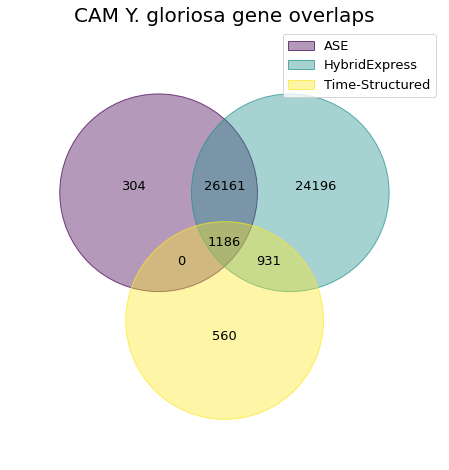

In [65]:
phys_plot_venn("CAM","./ASE_HE_maSigPro_venns")

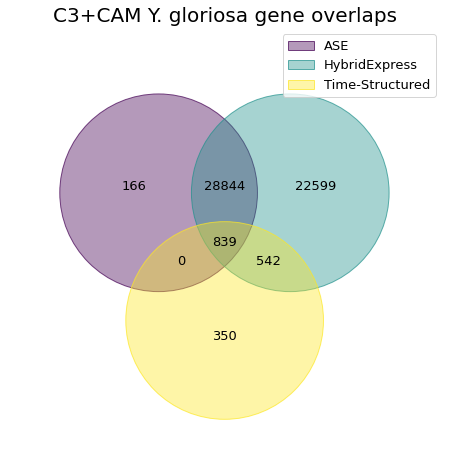

In [66]:
phys_plot_venn("C3+CAM","./ASE_HE_maSigPro_venns")

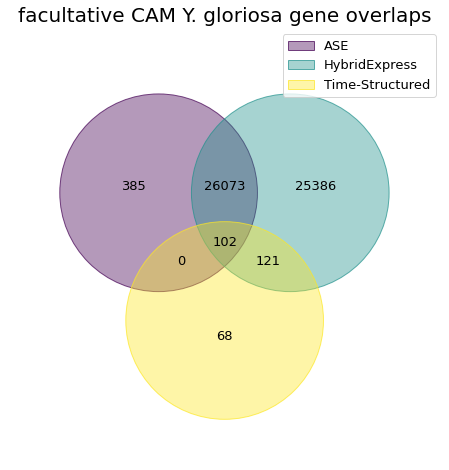

In [67]:
phys_plot_venn("facultative_CAM","./ASE_HE_maSigPro_venns")